In [14]:
import pandas as pd
import numpy as np
import yfinance as yf

In [15]:
# The Granger causality test is a statistical test used with time-series data to check whether the past
# values of one variable contain useful information for predicting another variable.

# Importantly, Granger causality does not prove true cause-and-effect. It means predictive causality.

In [16]:
data = yf.download("AAPL", start="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [17]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404053,186.170331,181.675131,184.895860,82488700
2024-01-03,182.030762,183.641134,181.220631,182.001124,58414500
2024-01-04,179.718933,180.884713,178.701340,179.956033,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [18]:
df=data.iloc[:,:-1]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 667 entries, 2024-01-02 to 2026-08-28
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  666 non-null    float64
 1   (High, AAPL)   666 non-null    float64
 2   (Low, AAPL)    666 non-null    float64
 3   (Open, AAPL)   666 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [20]:
df.dropna(inplace=True)

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

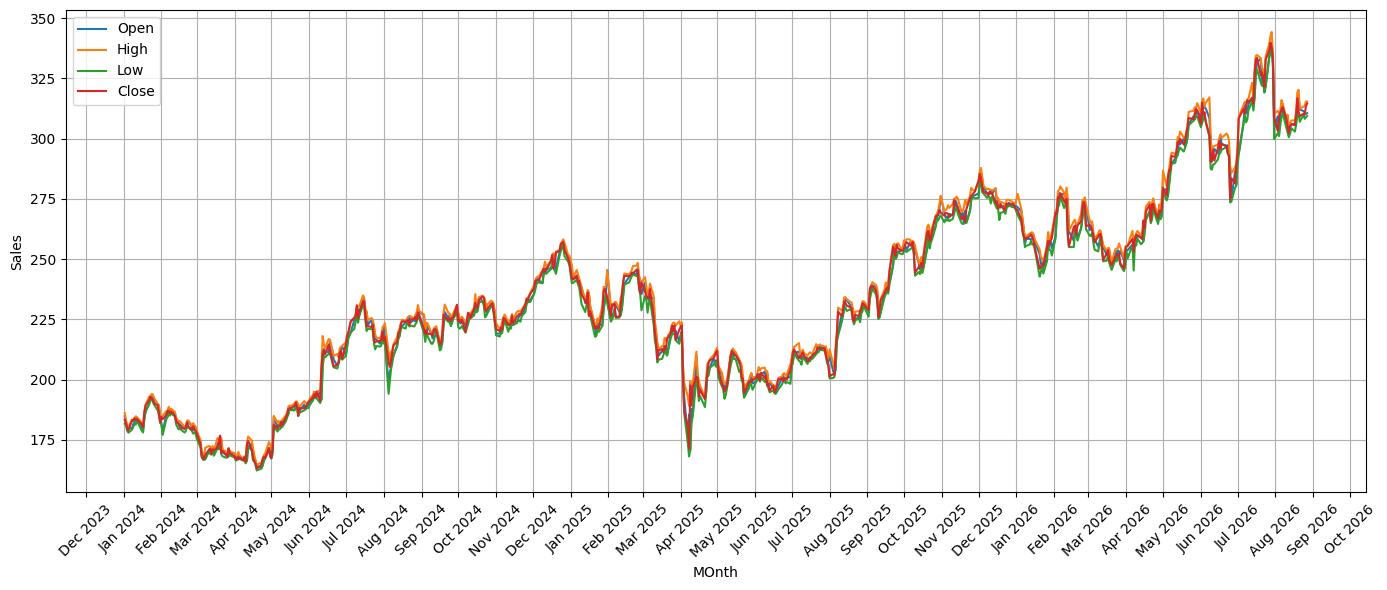

In [22]:
plt.figure(figsize=(14, 6))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df.index, df[col], label=col)
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('MOnth')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

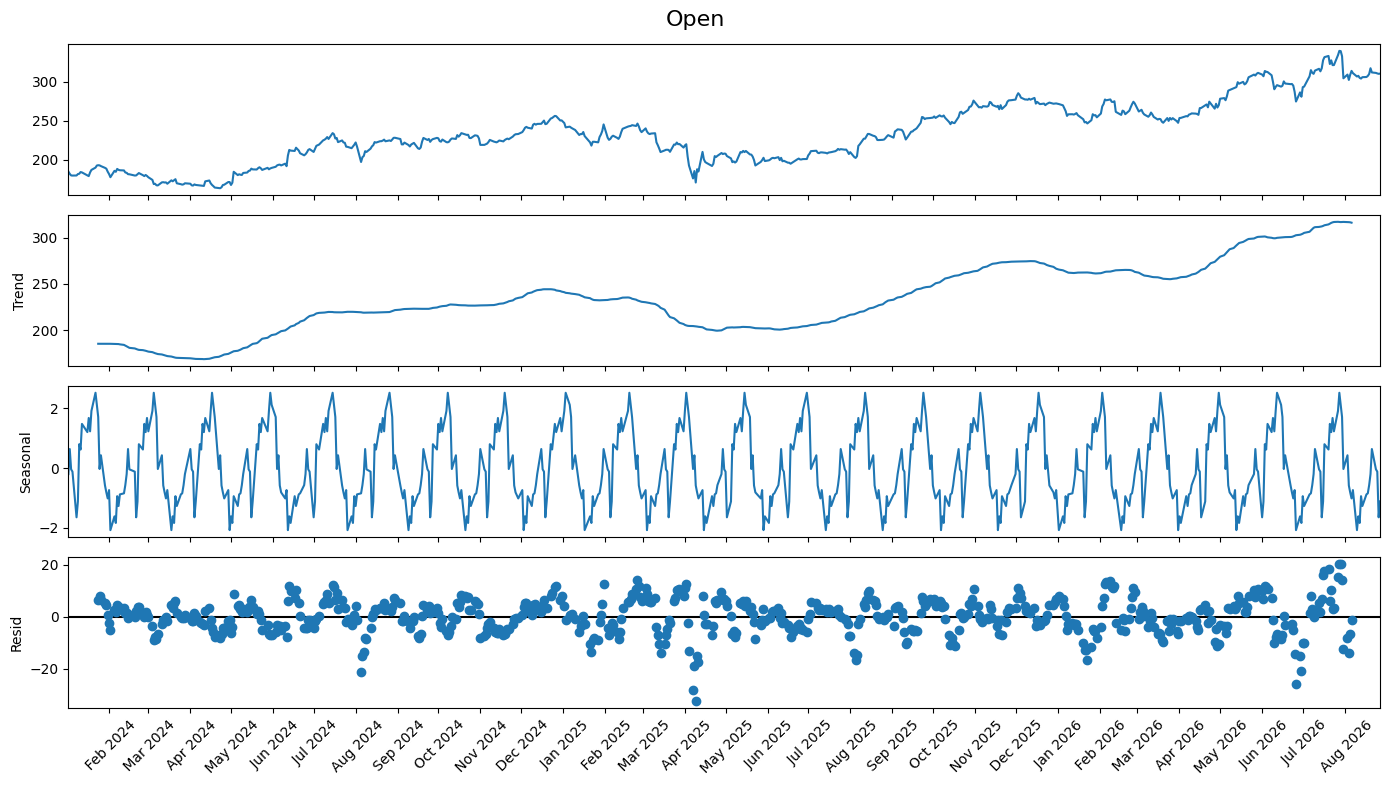

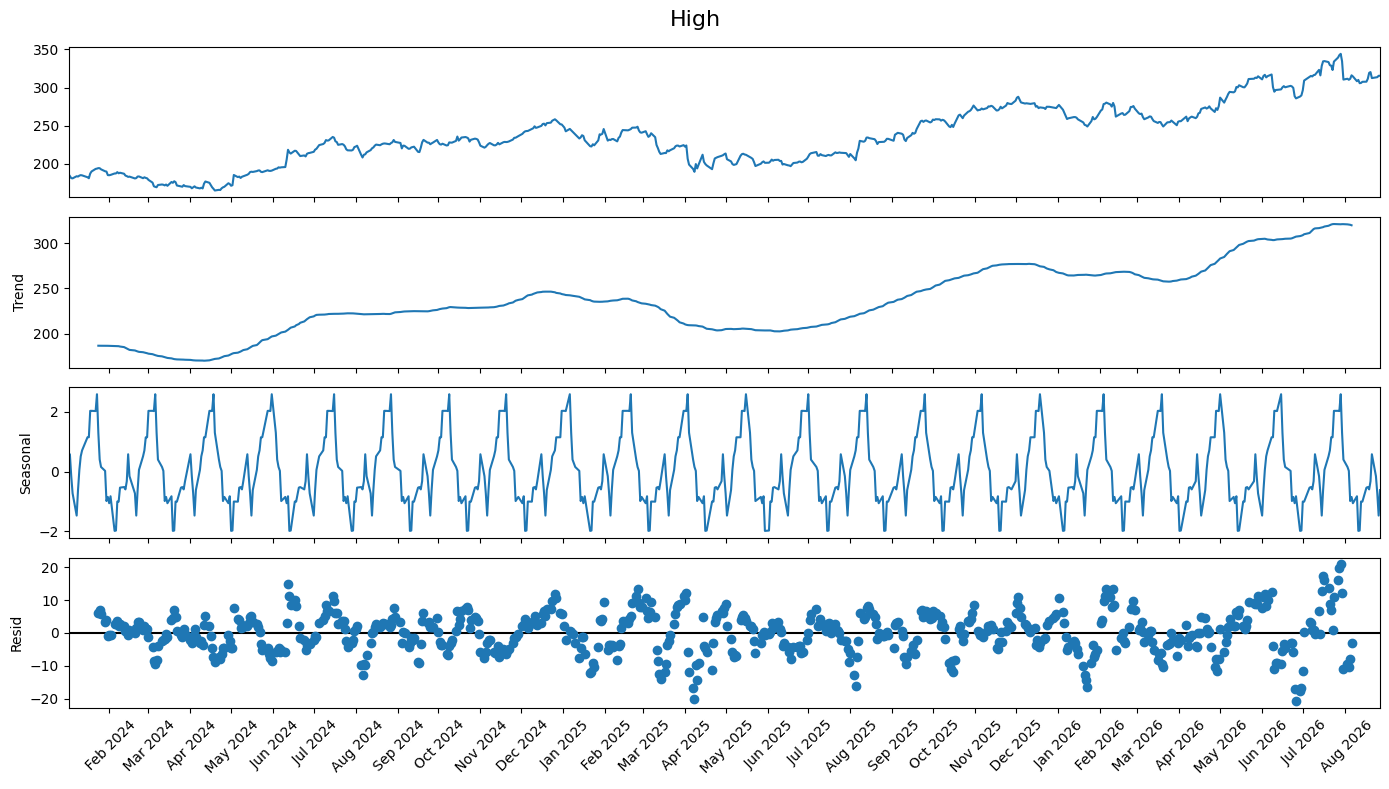

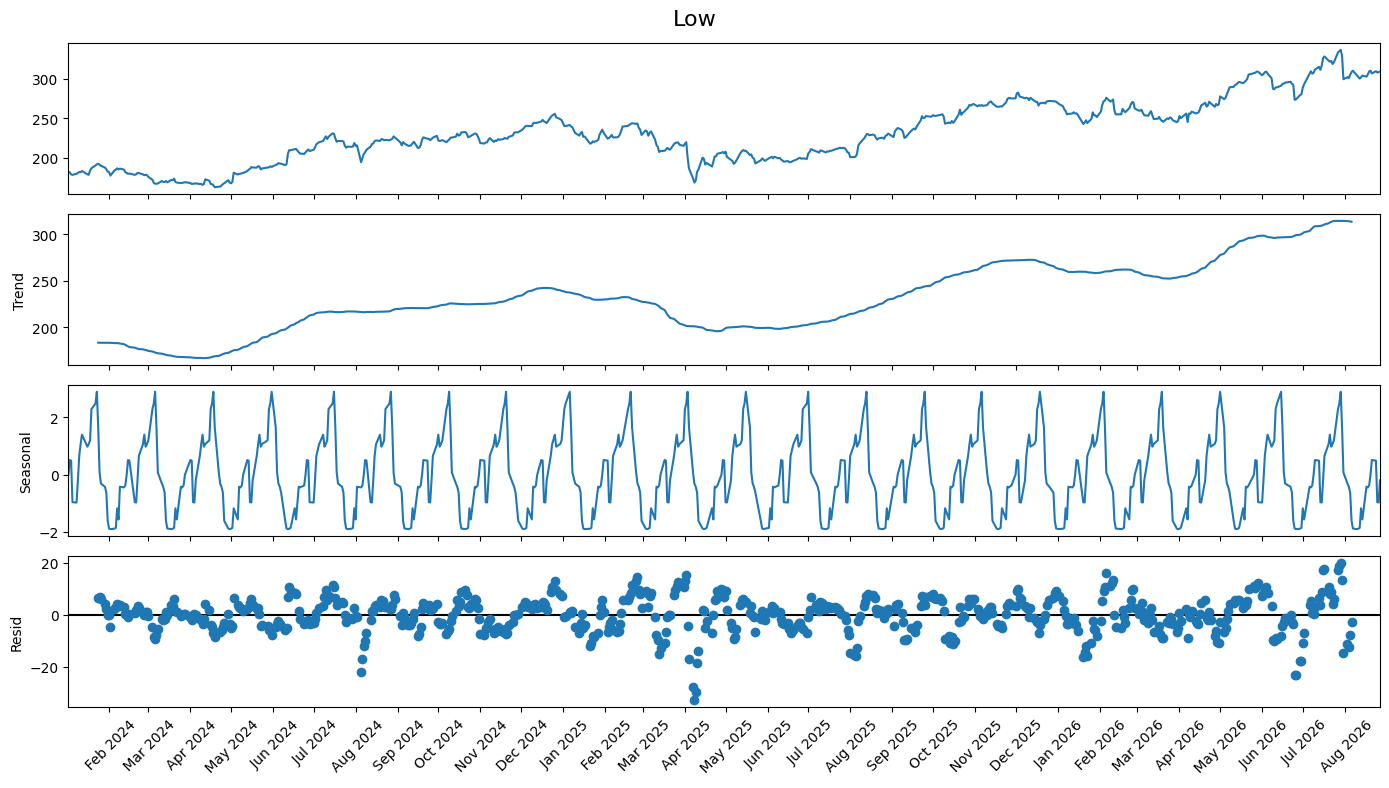

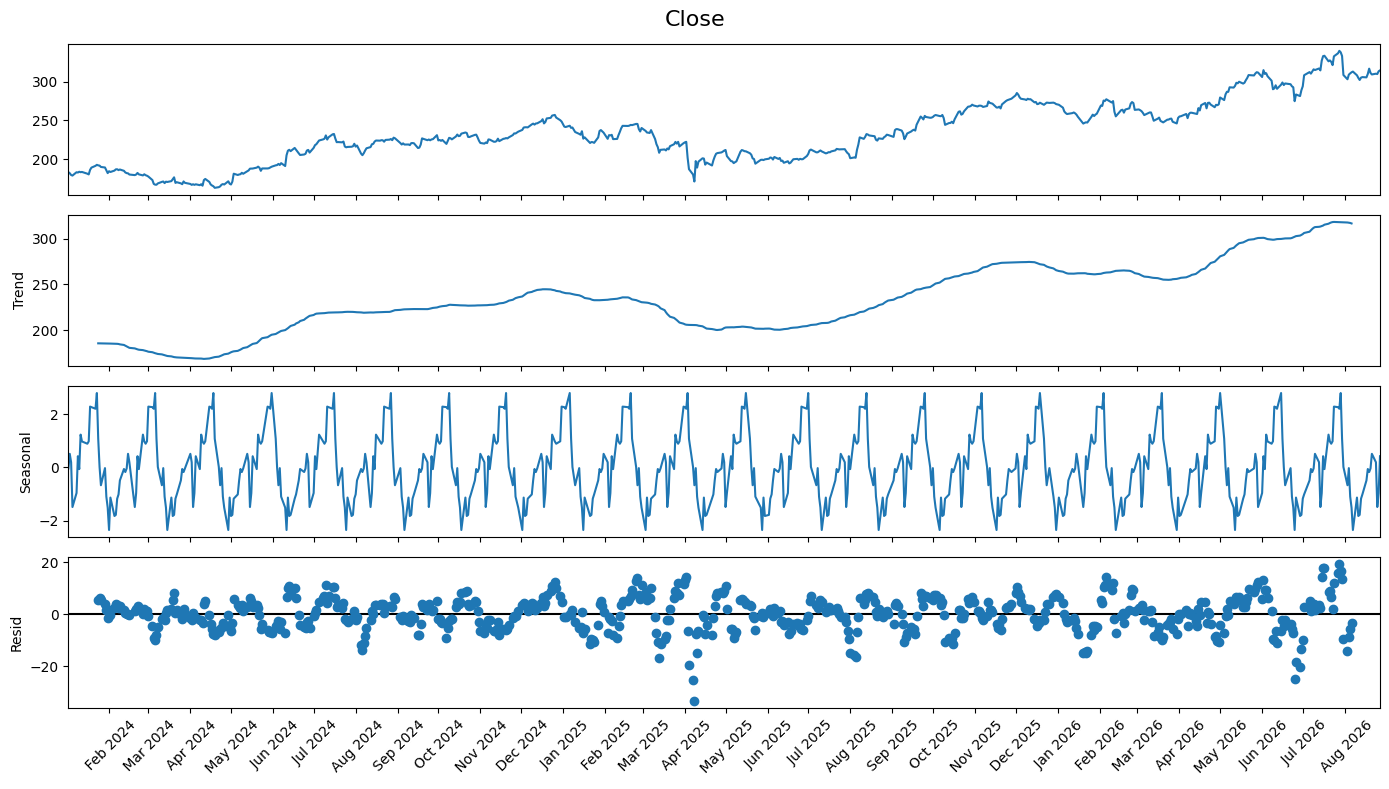

In [24]:
import matplotlib.dates as mdates
for col in ['Open', 'High', 'Low', 'Close']:
    result=seasonal_decompose(
        df[col],model='additive',period=30)
    fig=result.plot()
    fig.set_size_inches(14, 8)
    for ax in fig.axes:
         ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
         ax.xaxis.set_major_formatter(mdates.DateFormatter(" %b %Y"))
         ax.tick_params(axis="x", rotation=45)
    
    plt.suptitle(col,fontsize=16)
    plt.tight_layout()
    plt.show()

In [25]:
df_diff=df.diff().dropna()
from statsmodels.tsa.stattools import adfuller

In [26]:
for col in df_diff.columns:
    result = adfuller(df_diff[col])

    print(f"\n{col}")
    print("ADF statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Stationary after first difference")
    else:
        print("Still non-stationary")


('Close', 'AAPL')
ADF statistic: -13.064495061887438
p-value: 2.0154855367806977e-24
Stationary after first difference

('High', 'AAPL')
ADF statistic: -14.001332608424528
p-value: 3.8572353934059616e-26
Stationary after first difference

('Low', 'AAPL')
ADF statistic: -13.984932008419465
p-value: 4.1136656352709964e-26
Stationary after first difference

('Open', 'AAPL')
ADF statistic: -15.733025855084819
p-value: 1.2825835332025823e-28
Stationary after first difference


In [28]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
#A cointegration test checks whether two or more non-stationary time series have a stable long-run relationship.
data = df.dropna()

johansen_result = coint_johansen(
    data,
    det_order=0,
    k_ar_diff=1
)
# H₀: No cointegrating relationship (r = 0)
# H₁: At least 1 cointegrating relationship (r > 0)

In [29]:
johansen_result

In [30]:
johansen_result.lr1[0]

np.float64(770.2611926972587)

In [31]:
johansen_result.cvt[0, 1]

np.float64(47.8545)

In [34]:
print("Trace statistics:")
print(johansen_result.lr1[0])

print("\nCritical values:")
print(johansen_result.cvt[0,1])
print("you reject the null hypothesis of no cointegration because 770 trace is > 47 critical values")

Trace statistics:
770.2611926972587

Critical values:
47.8545
you reject the null hypothesis of no cointegration because 770 trace is > 47 critical values


In [35]:
print("Trace statistics:")
print(johansen_result.lr1)

print("\nCritical values:")
print(johansen_result.cvt[:,1])

Trace statistics:
[770.2611927  405.97629771 124.10433093   1.0716173 ]

Critical values:
[47.8545 29.7961 15.4943  3.8415]


In [20]:

for i in range(len(johansen_result.lr1)):

    trace = johansen_result.lr1[i]
    critical = johansen_result.cvt[i, 1]

    print(
        f"Rank <= {i}: "
        f"trace={trace:.4f}, "
        f"critical={critical:.4f}, "
        f"reject={trace > critical}"
    )

Rank <= 0: trace=759.4701, critical=47.8545, reject=True
Rank <= 1: trace=398.7545, critical=29.7961, reject=True
Rank <= 2: trace=120.9443, critical=15.4943, reject=True
Rank <= 3: trace=1.4149, critical=3.8415, reject=False


In [36]:
#Your cointegration rank is 3
#Your four variables have 3 independent long-run cointegrating relationships.

In [21]:
# Because it determines your model.

# Result	      Interpretation	Typical model
# r=0	         No cointegration	VAR on differences
# 0<r<4	         Cointegrated	    VECM
# r=4	         Full rank	        Usually indicates variables are stationary / setup needs review


# the Johansen test suggests there are 3 independent stationary long-run combinations among those four variables.

# In general, with n=4 variables:

# 0<r<n

# means the system is cointegrated.

# Your case:

# n=4,r=3

# So:

# 3 cointegrating relationships
# 

# and there is effectively one common stochastic trend driving the system.

In [25]:
# So your four variables are non-stationary individually but have 3 long-run relationships.

# VECM is designed exactly for this situation

# k_ar_diff=p−1​ order of autoregressive lags/orders

In [37]:
from statsmodels.tsa.vector_ar.vecm import VECM
#You would typically use it when you have multiple time-series variables that are cointegrated—which is exactly
#the situation your Johansen test suggests.

In [38]:
model = VECM(
    df,
    k_ar_diff=1,
    coint_rank=3,
    deterministic='ci'
)

results = model.fit()

print(results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Close_AAPL
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.Close_AAPL     0.0890      0.125      0.715      0.475      -0.155       0.333
L1.High_AAPL     -0.1113      0.116     -0.960      0.337      -0.339       0.116
L1.Low_AAPL       0.1232      0.121      1.023      0.306      -0.113       0.359
L1.Open_AAPL      0.1148      0.103      1.119      0.263      -0.086       0.316
Det. terms outside the coint. relation & lagged endog. parameters for equation High_AAPL
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.Close_AAPL     0.0181      0.104      0.174      0.862      -0.186       0.222
L1.High_AAPL     -0.1354      0.097     -1.399      0.162      -0.325       0.054
L

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [27]:
# deterministic='n'   no deterministic terms
# deterministic='ci'  constant inside cointegration
# deterministic='co'  constant outside cointegration
# deterministic='li'  linear trend inside cointegration
# deterministic='lo'  linear trend outside cointegration

In [39]:
from statsmodels.tsa.stattools import grangercausalitytests

In [42]:
X=data.iloc[:,0]

In [45]:
Y=data.iloc[:,3]
Y

Date
2024-01-02    184.895860
2024-01-03    182.001124
2024-01-04    179.956033
2024-01-05    179.797983
2024-01-08    179.896761
                 ...    
2026-08-21    312.049988
2026-08-24    311.470001
2026-08-25    310.790009
2026-08-26    310.299988
2026-08-27    310.549988
Name: (Open, AAPL), Length: 666, dtype: float64

In [47]:
X = data.iloc[:, 0]
Y = data.iloc[:, 3]

test_data = data.iloc[:, [3, 0]]   # Y first, X second



In [49]:
# p < 0.05  → evidence of Granger causality
# p > 0.05  → no sufficient evidence

In [48]:
result = grangercausalitytests(
    test_data,
    maxlag=7,
    verbose=True
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1024.9411, p=0.0000  , df_denom=662, df_num=1
ssr based chi2 test:   chi2=1029.5858, p=0.0000  , df=1
likelihood ratio test: chi2=622.0454, p=0.0000  , df=1
parameter F test:         F=1024.9411, p=0.0000  , df_denom=662, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=521.8730, p=0.0000  , df_denom=659, df_num=2
ssr based chi2 test:   chi2=1051.6651, p=0.0000  , df=2
likelihood ratio test: chi2=630.3179, p=0.0000  , df=2
parameter F test:         F=521.8730, p=0.0000  , df_denom=659, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=342.2671, p=0.0000  , df_denom=656, df_num=3
ssr based chi2 test:   chi2=1037.7579, p=0.0000  , df=3
likelihood ratio test: chi2=624.5820, p=0.0000  , df=3
parameter F test:         F=342.2671, p=0.0000  , df_denom=656, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=251.8181, p=0.0